In [109]:
import pandas as pd

data = {
    "Experience_Years": [1,3,5,2,8,10,4,6,1,9,2,7,3,5,1,8,6,4,10,2],
    "Performance_Score": [3,6,8,4,9,10,5,7,2,9,3,8,5,6,2,10,7,5,9,3],
    "Projects_Completed": [1,4,7,2,10,12,5,8,1,11,2,9,4,6,1,10,7,5,12,2],
    "Attendance_Percent": [70,85,95,75,98,99,80,90,65,97,72,93,82,88,68,96,89,81,98,70],
    "Department": ["Sales","IT","IT","HR","IT","IT","Sales","HR","Sales","IT",
                   "HR","IT","Sales","HR","Sales","IT","HR","Sales","IT","HR"],
    "Promotion": ["No","Yes","Yes","No","Yes","Yes","No","Yes","No","Yes",
                  "No","Yes","No","Yes","No","Yes","Yes","No","Yes","No"]
}

df = pd.DataFrame(data)
print(df)

    Experience_Years  Performance_Score  Projects_Completed  \
0                  1                  3                   1   
1                  3                  6                   4   
2                  5                  8                   7   
3                  2                  4                   2   
4                  8                  9                  10   
5                 10                 10                  12   
6                  4                  5                   5   
7                  6                  7                   8   
8                  1                  2                   1   
9                  9                  9                  11   
10                 2                  3                   2   
11                 7                  8                   9   
12                 3                  5                   4   
13                 5                  6                   6   
14                 1                  2                

In [110]:
df_encoded = pd.get_dummies(df,columns=["Department"],drop_first=True)
print(df_encoded)

    Experience_Years  Performance_Score  Projects_Completed  \
0                  1                  3                   1   
1                  3                  6                   4   
2                  5                  8                   7   
3                  2                  4                   2   
4                  8                  9                  10   
5                 10                 10                  12   
6                  4                  5                   5   
7                  6                  7                   8   
8                  1                  2                   1   
9                  9                  9                  11   
10                 2                  3                   2   
11                 7                  8                   9   
12                 3                  5                   4   
13                 5                  6                   6   
14                 1                  2                

In [111]:
X =df_encoded.drop(columns=["Promotion"])
y = df_encoded["Promotion"]

In [112]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=42)


In [113]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    # n_estimators=50,
    # max_depth=4,
    # max_features="sqrt",
    # bootstrap=True,
    # oob_score=True,
    random_state=42
)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [114]:
from sklearn.metrics import accuracy_score

y_pred= model.predict(X_test)

print("PRIDICTION VALUES : ",y_pred)
print("ACTUAL VALUES : ",y_test)

print("ACCURACY : ",accuracy_score(y_pred,y_test)*100)

print("OOB ACCURACY : ",model.oob_score)

PRIDICTION VALUES :  ['No' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No']
ACTUAL VALUES :  0      No
17     No
15    Yes
1     Yes
8      No
5     Yes
11    Yes
3      No
Name: Promotion, dtype: str
ACCURACY :  87.5
OOB ACCURACY :  False


In [115]:
which_column_is_more_imp_for_decision = pd.Series(model.feature_importances_,index=X.columns)

print(which_column_is_more_imp_for_decision)

Experience_Years      0.267533
Performance_Score     0.211190
Projects_Completed    0.196429
Attendance_Percent    0.263000
Department_IT         0.023514
Department_Sales      0.038333
dtype: float64


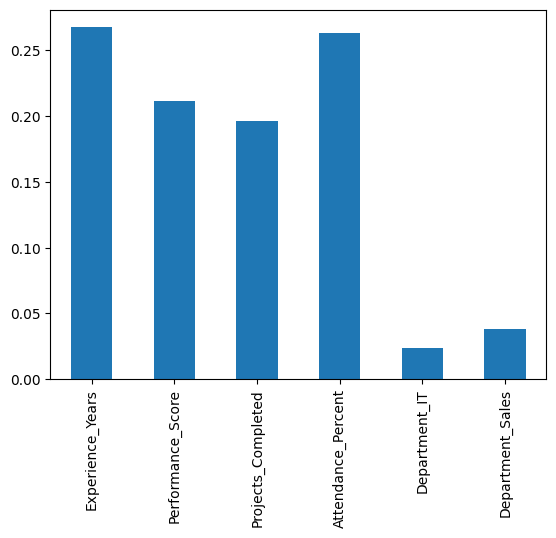

In [116]:
import matplotlib.pyplot as plt
which_column_is_more_imp_for_decision.plot(kind="bar")
plt.show()

In [117]:
new_employee = pd.DataFrame({
    "Experience_Years": [4],
    "Performance_Score": [7],
    "Projects_Completed": [5],
    "Attendance_Percent": [90],
    "Department_IT": [1],
    "Department_Sales": [0]
})

prediction = model.predict(new_employee)
print("Promotion Prediction:", prediction)

Promotion Prediction: ['Yes']


In [146]:
new_emp = pd.DataFrame ({
    "Experience_Years" : [8],
    "Performance_Score" : [7],
    "Projects_Completed" : [6],
    "Attendance_Percent" : [80],
    "Department_IT": [1],
    "Department_Sales": [0]
})

pridiction = model.predict(new_emp)
print("PROMOTION STATUS OF THIS INFORMATIOn: ",pridiction)

PROMOTION STATUS OF THIS INFORMATIOn:  ['Yes']
